In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load dataset
df = pd.read_csv('Dataset/resumeJD2_pairs.csv', engine='python', on_bad_lines='skip')
print(f"Data Loaded Successfully: {df.shape[0]:,} rows, {df.shape[1]} columns")

Data Loaded Successfully: 500 rows, 4 columns


In [13]:
print(f"\nColumns: {list(df.columns)}")


Columns: ['resume_text', 'job_description', 'match_score', 'match_label']


In [8]:
# First 5 data
print("First 5 rows:")
df.tail()

First 5 rows:


,resume_text,job_description,match_score,match_label
495,Name: Meera Nair || Email: meera.nair40@gmail....,Job Title: AI Engineer || Company: Capgemini |...,0.55,partial match
496,Name: Divya Menon || Email: divya.menon41@gmai...,Job Title: Security Analyst || Company: Byju's...,0.79,match
497,Name: Zara Singh || Email: zara.singh90@gmail....,Job Title: Platform Engineer || Company: HDFC ...,0.96,match
498,Name: Mohit Chopra || Email: mohit.chopra44@gm...,Job Title: Senior Financial Analyst || Company...,0.24,no match
499,Name: Shreya Saxena || Email: shreya.saxena63@...,Job Title: Credit Analyst || Company: CRED | L...,0.31,no match


In [10]:
# dataset information
print("Dataset Info:")
print("=" * 60)
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resume_text      500 non-null    object 
 1   job_description  500 non-null    object 
 2   match_score      500 non-null    float64
 3   match_label      500 non-null    object 
dtypes: float64(1), object(3)
memory usage: 15.8+ KB


In [9]:
df.describe()

,match_score
count,500.000000
mean,0.529720
std,0.283882
min,0.050000
25%,0.280000
50%,0.540000
75%,0.790000
max,0.980000


In [11]:
# statistical summary
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,match_score
count,500.000000
mean,0.529720
std,0.283882
min,0.050000
25%,0.280000
50%,0.540000
75%,0.790000
max,0.980000


In [12]:
# text columns summary
print("\nText Columns Summary:")
df.describe(include='object')


Text Columns Summary:


,resume_text,job_description,match_label
count,500,500,500
unique,500,500,3
top,Name: Shreya Saxena || Email: shreya.saxena63@...,Job Title: Credit Analyst || Company: CRED | L...,no match
freq,1,1,190


In [14]:
# Check for the missing values
print("Missing Values Analysis:")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
})
print(missing_df)
print(f"\nTotal missing values: {missing.sum()}")

Missing Values Analysis:
                 Missing_Count  Percentage
resume_text                  0         0.0
job_description              0         0.0
match_score                  0         0.0
match_label                  0         0.0

Total missing values: 0


In [15]:
full_dupes = df.duplicated().sum()
print(f"Full duplicate rows: {full_dupes}")

Full duplicate rows: 0


In [16]:
pair_dupes = df.duplicated(subset=['resume_text', 'job_description']).sum()
print(f"Duplicate resume+JD pairs: {pair_dupes}")

Duplicate resume+JD pairs: 0


In [17]:
# ─── Section: Uniqueness Checks ───────────────────────────────────────────────

print(f"Total rows:          {len(df)}")
print(f"Unique resumes:      {df['resume_text'].nunique()}")
print(f"Unique JDs:          {df['job_description'].nunique()}")
print(f"Unique resume+JD pairs: {df[['resume_text','job_description']].drop_duplicates().shape[0]}")

Total rows:          500
Unique resumes:      500
Unique JDs:          500
Unique resume+JD pairs: 500


In [18]:
# ─── Section: Label Consistency ───────────────────────────────────────────────

# What labels exist? (spot the case inconsistency!)
print("Unique labels found:")
print(df['match_label'].value_counts())

# Is the casing consistent?
print(f"\nExpected 3 labels, got: {df['match_label'].nunique()} unique values")
print("Distinct values:", df['match_label'].unique())

Unique labels found:
match_label
no match         190
match            158
partial match    152
Name: count, dtype: int64

Expected 3 labels, got: 3 unique values
Distinct values: ['partial match' 'no match' 'match']


In [19]:
print("Score distribution:")
print(df['match_score'].describe())
print()

# Scores must be between 0.0 and 1.0 — flag the bad ones
invalid_scores = df[(df['match_score'] < 0) | (df['match_score'] > 1)]
print(f"Invalid scores (out of 0–1 range): {len(invalid_scores)}")
print(invalid_scores[['match_label', 'match_score']])

Score distribution:
count    500.000000
mean       0.529720
std        0.283882
min        0.050000
25%        0.280000
50%        0.540000
75%        0.790000
max        0.980000
Name: match_score, dtype: float64

Invalid scores (out of 0–1 range): 0
Empty DataFrame
Columns: [match_label, match_score]
Index: []


In [20]:
# ─── Section: Label vs Score Sanity Check ─────────────────────────────────────
# Do scores actually match what the label says?

print("Score stats per label (after lowercasing):")
df['match_label_lower'] = df['match_label'].str.lower()
print(df.groupby('match_label_lower')['match_score'].describe().round(2))

Score stats per label (after lowercasing):
                   count  mean   std   min   25%   50%   75%   max
match_label_lower                                                 
match              158.0  0.86  0.07  0.75  0.80  0.86  0.93  0.98
no match           190.0  0.22  0.10  0.05  0.13  0.22  0.31  0.39
partial match      152.0  0.57  0.10  0.40  0.48  0.58  0.67  0.74


In [21]:
# ─── Summary: All issues found ────────────────────────────────────────────────

print("=" * 50)
print("DATA QUALITY REPORT — merged_dataset.csv")
print("=" * 50)
print(f"  Total rows:             {len(df)}")
print(f"  Full duplicates:        {df.duplicated().sum()}")
print(f"  Duplicate pairs:        {df.duplicated(subset=['resume_text','job_description']).sum()}")
print(f"  Null resume_text:       {df['resume_text'].isnull().sum()}")
print(f"  Null job_description:   {df['job_description'].isnull().sum()}")
print(f"  Label case variants:    {df['match_label'].nunique()} (expected 3)")
print(f"  Invalid scores (<0/>1): {((df['match_score'] < 0) | (df['match_score'] > 1)).sum()}")
print("=" * 50)

DATA QUALITY REPORT — merged_dataset.csv
  Total rows:             500
  Full duplicates:        0
  Duplicate pairs:        0
  Null resume_text:       0
  Null job_description:   0
  Label case variants:    3 (expected 3)
  Invalid scores (<0/>1): 0


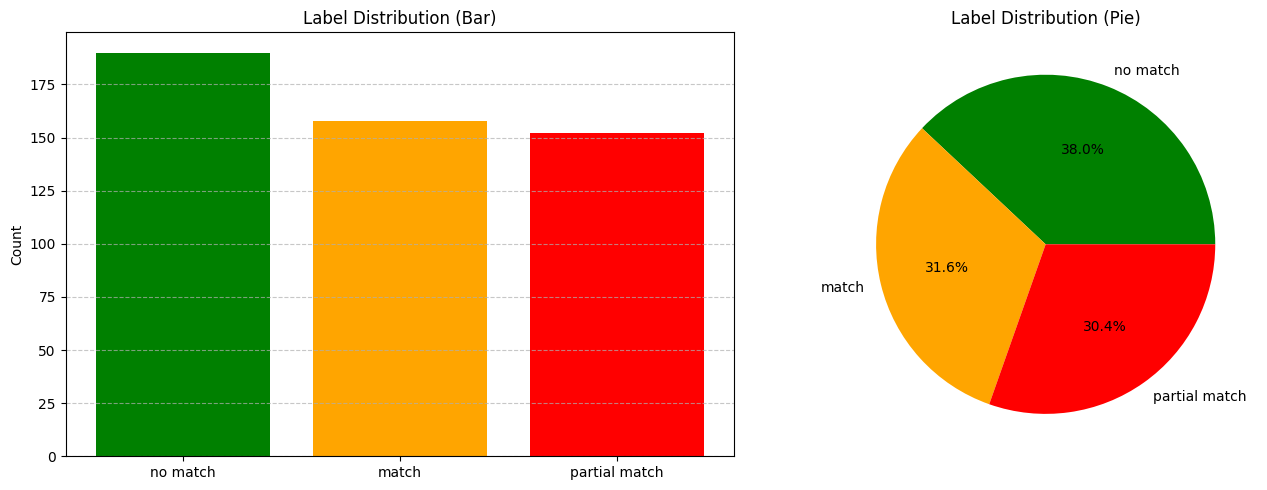

In [23]:
# Pie chart + bar side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['match_label'].str.lower().value_counts()

axes[0].bar(counts.index, counts.values, color=['green','orange','red'])
axes[0].set_title('Label Distribution (Bar)')
axes[0].set_ylabel('Count')
axes[0].grid(True, axis='y', linestyle='--', alpha=0.7)  # Add grid

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['green','orange','red'])
axes[1].set_title('Label Distribution (Pie)')

plt.tight_layout()
plt.show()

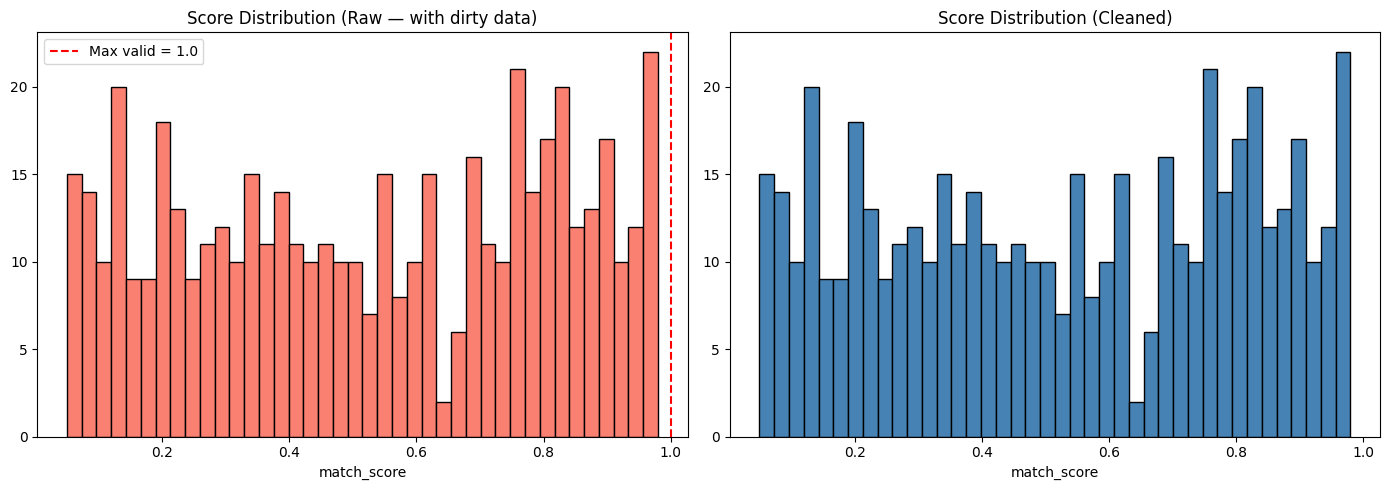

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before cleaning
axes[0].hist(df['match_score'], bins=40, color='salmon', edgecolor='black')
axes[0].set_title('Score Distribution (Raw — with dirty data)')
axes[0].set_xlabel('match_score')
axes[0].axvline(1.0, color='red', linestyle='--', label='Max valid = 1.0')
axes[0].legend()

# After cleaning
clean = df[(df['match_score'] >= 0) & (df['match_score'] <= 1)]
axes[1].hist(clean['match_score'], bins=40, color='steelblue', edgecolor='black')
axes[1].set_title('Score Distribution (Cleaned)')
axes[1].set_xlabel('match_score')

plt.tight_layout()
plt.show()

The histogram plots of match_score "before" and "after" are nearly identical, it means:
*   There were no significant invalid values to remove.
*   The cleaning step served as a validation check rather than making substantial changes.
* The cleaned dataset is confirmed to be suitable for subsequent preprocessing and model training.



/tmp/ipykernel_3457/3598416276.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x='match_label', y='match_score',


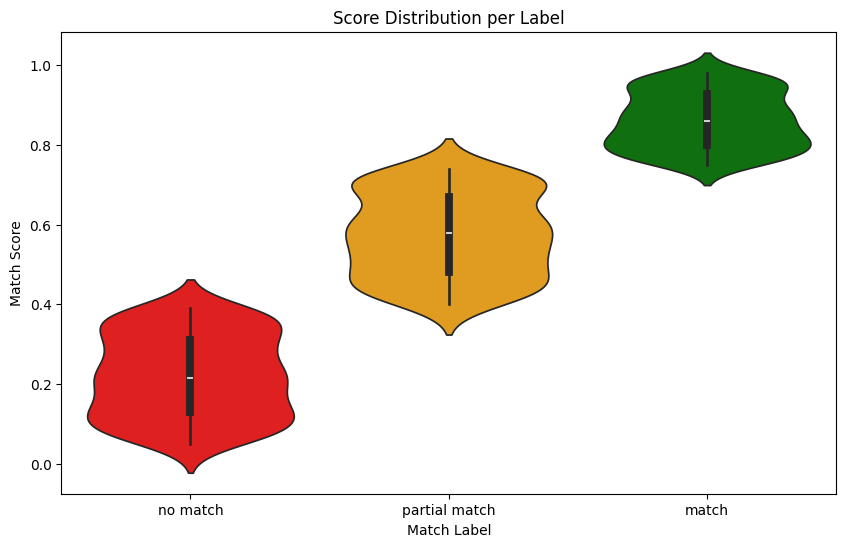

In [26]:
import seaborn as sns

df_plot = df.copy()
df_plot['match_label'] = df_plot['match_label'].str.lower()
df_plot = df_plot[(df_plot['match_score'] >= 0) & (df_plot['match_score'] <= 1)]

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_plot, x='match_label', y='match_score',
               order=['no match','partial match','match'],
               palette=['red','orange','green'])
plt.title('Score Distribution per Label')
plt.xlabel('Match Label')
plt.ylabel('Match Score')
plt.show()

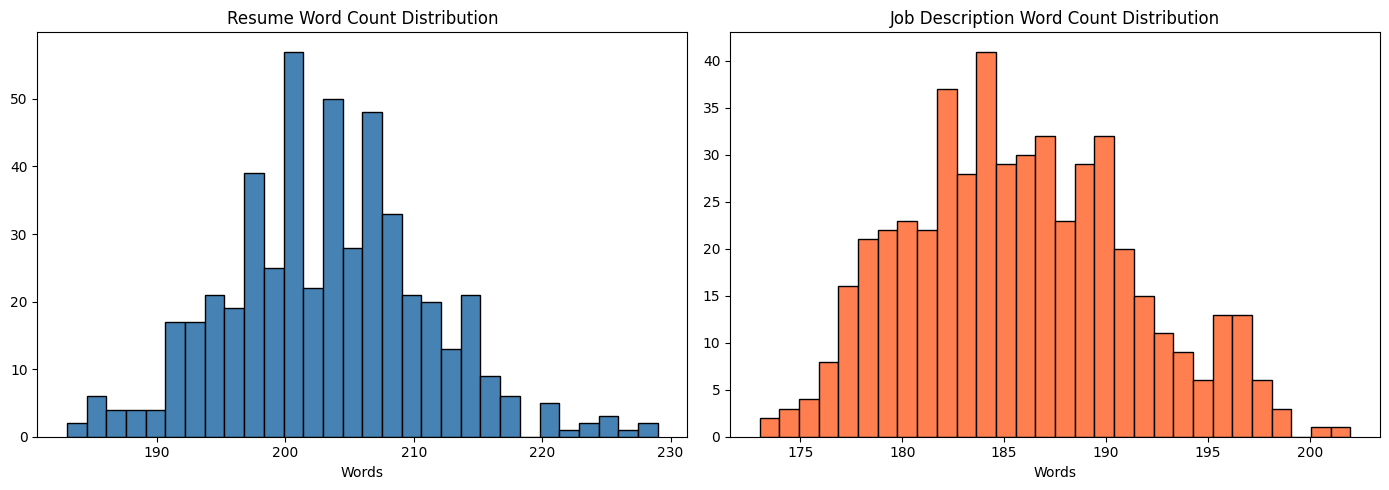

In [27]:
df_plot['resume_len'] = df_plot['resume_text'].str.split().str.len()
df_plot['jd_len']     = df_plot['job_description'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_plot['resume_len'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Resume Word Count Distribution')
axes[0].set_xlabel('Words')

axes[1].hist(df_plot['jd_len'], bins=30, color='coral', edgecolor='black')
axes[1].set_title('Job Description Word Count Distribution')
axes[1].set_xlabel('Words')

plt.tight_layout()
plt.show()

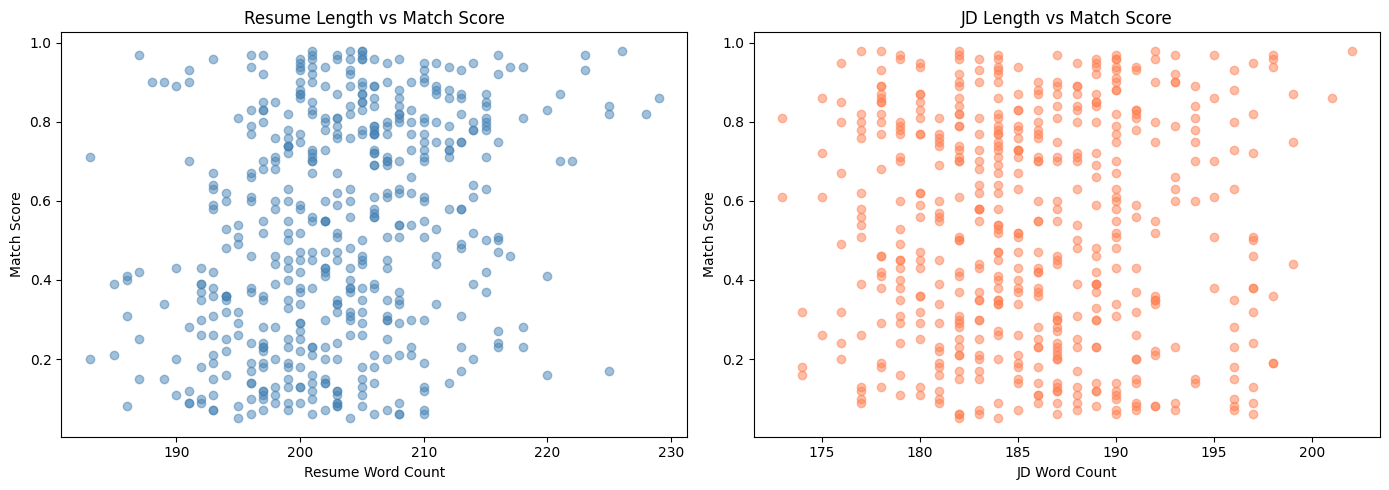

Resume length correlation: 0.286
JD length correlation:     0.001


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_plot['resume_len'], df_plot['match_score'], alpha=0.5, color='steelblue')
axes[0].set_xlabel('Resume Word Count')
axes[0].set_ylabel('Match Score')
axes[0].set_title('Resume Length vs Match Score')

axes[1].scatter(df_plot['jd_len'], df_plot['match_score'], alpha=0.5, color='coral')
axes[1].set_xlabel('JD Word Count')
axes[1].set_ylabel('Match Score')
axes[1].set_title('JD Length vs Match Score')

plt.tight_layout()
plt.show()

# Actual correlation values
print("Resume length correlation:", df_plot['resume_len'].corr(df_plot['match_score']).round(3))
print("JD length correlation:    ", df_plot['jd_len'].corr(df_plot['match_score']).round(3))


**Resume length correlation: 0.286** (a weak positive correlation.)

- longer resumes tend to have slightly higher match scores, but the relationship is not strong.

**JD length correlation: 0.001** (essentially zero correlation.)
- the length of the job description has virtually no relationship with the match score.

*Whether a job description is short or long does not significantly affect the matching score.*
- good sign for an ATS.
- If very high correlation (e.g., 0.8 or 0.9), it could suggest that the matching algorithm is biased toward longer resumes or longer job descriptions rather than their actual content.
- Ideally, an ATS should match based on skills, experience, education, and semantic similarity, not simply on document length.

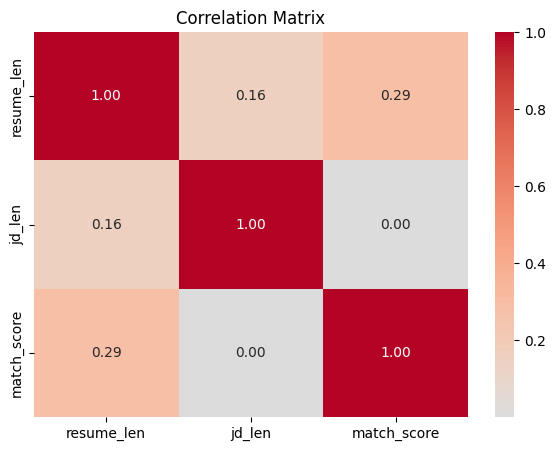

In [29]:
plt.figure(figsize=(7, 5))
corr = df_plot[['resume_len', 'jd_len', 'match_score']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [30]:
pip install wordcloud

*A word cloud is a visualization that displays the most frequently occurring words in a text. The more often a word appears, the larger it is displayed.*

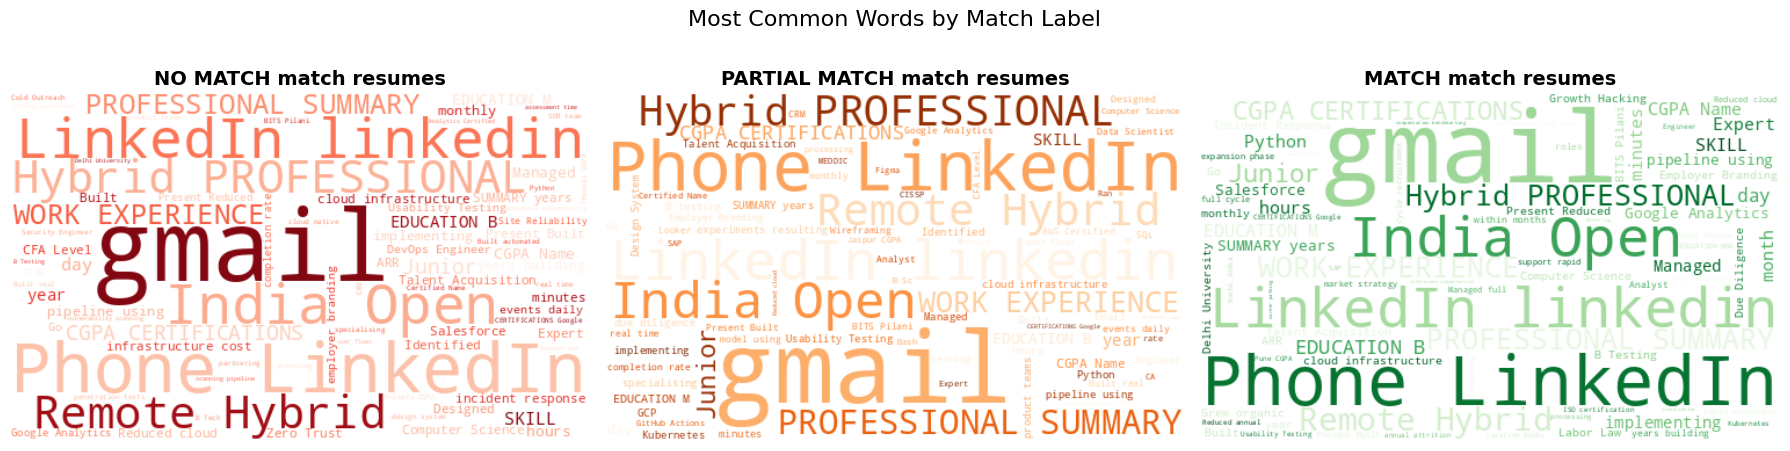

In [32]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels  = ['no match','partial match','match']
colors  = ['Reds', 'Oranges', 'Greens']

for ax, label, cmap in zip(axes, labels, colors):
    text = ' '.join(df_plot[df_plot['match_label'] == label]['resume_text'].dropna())
    wc = WordCloud(width=500, height=300, background_color='white',
                   colormap=cmap, max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{label.upper()} match resumes', fontsize=14, fontweight='bold')

plt.suptitle('Most Common Words by Match Label', fontsize=16)
plt.tight_layout()
plt.show()
